# Target Pipeline EDA and Analysis

Run the pipeline first so the files under `output/` exist, then run this notebook top to bottom. It covers the EDA and analysis checklist from the case study.

In [27]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
OUTPUT_DIR = PROJECT_ROOT / "output"
INSIGHTS_PATH = OUTPUT_DIR / "insights.json"
CLEANED_DATA_PATH = OUTPUT_DIR / "cleaned__target_data.csv"
CITY_REPORT_DIR = OUTPUT_DIR / "sales_by_city_report"

if not INSIGHTS_PATH.exists() or not CLEANED_DATA_PATH.exists():
    raise FileNotFoundError("Run the pipeline first so output/insights.json and output/cleaned__target_data.csv exist.")

with INSIGHTS_PATH.open("r", encoding="utf-8") as file:
    insights = json.load(file)

raw_df = pd.read_csv(CLEANED_DATA_PATH)
city_report_paths = sorted(CITY_REPORT_DIR.glob("part-*.csv"))
city_report_df = pd.read_csv(city_report_paths[0]) if city_report_paths else pd.DataFrame()

df = raw_df.copy()
timestamp_columns = [
    "order_purchase_timestamp",
    "order_aproved_at",
    "order_delivered_customer_date",
]
numeric_columns = [
    "Id",
    "order_products_value",
    "order_freight_value",
    "order_items_qty",
    "customer_zip_code_prefix",
    "review_score",
    "total_order_value",
    "approval_delay_hours",
    "delivery_time_days",
    "freight_ratio",
]

for column in timestamp_columns:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors="coerce")

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

df["order_year"] = df["order_purchase_timestamp"].dt.year
df["order_week"] = df["order_purchase_timestamp"].dt.to_period("W").astype(str)
df["order_date"] = df["order_purchase_timestamp"].dt.date

print(f"Loaded {len(df)} cleaned rows")
print(f"Insights keys: {', '.join(sorted(insights.keys()))}")

Loaded 978 cleaned rows
Insights keys: average_approval_delay_hours, average_delivery_time_days, average_freight_value, average_review_score, average_total_order_value, order_status_distribution, review_to_delivery_correlation, row_count, sales_by_city, sales_by_state


## Dataset Shape and Schema Check

In [28]:
pd.DataFrame(
    {
        "column": df.columns,
        "dtype": [str(dtype) for dtype in df.dtypes],
        "non_null_count": [int(df[column].notna().sum()) for column in df.columns],
    }
)

,column,dtype,non_null_count
0,Id,int64,978
1,order_status,object,978
2,order_products_value,float64,978
3,order_freight_value,float64,978
4,order_items_qty,int64,978
5,order_purchase_timestamp,datetime64[ns],978
6,order_aproved_at,datetime64[ns],978
7,order_delivered_customer_date,datetime64[ns],978
8,customer_city,object,978
9,customer_state,object,978


## EDA Checklist

In [29]:
eda_summary_df = pd.DataFrame(
    {
        "metric": [
            "row_count",
            "mean_order_products_value",
            "mean_order_freight_value",
            "unique_states",
            "missing_value_cells",
            "average_delivery_time_days",
            "average_approval_delay_hours",
            "average_review_score",
        ],
        "value": [
            len(df),
            df["order_products_value"].mean(),
            df["order_freight_value"].mean(),
            df["customer_state"].nunique(),
            int(df.isna().sum().sum()),
            df["delivery_time_days"].mean(),
            df["approval_delay_hours"].mean(),
            df.groupby("Id", as_index=False)["review_score"].mean()["review_score"].mean(),
        ],
    }
)

eda_summary_df

,metric,value
0,row_count,978.00
1,mean_order_products_value,127.85
2,mean_order_freight_value,21.41
3,unique_states,26.00
4,missing_value_cells,0.00
5,average_delivery_time_days,12.33
6,average_approval_delay_hours,10.41
7,average_review_score,4.09


In [37]:
missing_values_df = (
    df.isna()
    .sum()
    .rename("missing_values")
    .reset_index()
    .rename(columns={"index": "column"})
    .sort_values(["missing_values", "column"], ascending=[False, True])
)

missing_values_df

,column,missing_values
0,Id,0
13,approval_delay_hours,0
8,customer_city,0
9,customer_state,0
10,customer_zip_code_prefix,0
14,delivery_time_days,0
15,freight_ratio,0
6,order_aproved_at,0
18,order_date,0
7,order_delivered_customer_date,0


In [31]:
states_df = (
    df[["customer_state"]]
    .drop_duplicates()
    .sort_values("customer_state")
    .reset_index(drop=True)
)

print(f"Unique states: {states_df['customer_state'].nunique()}")
states_df.T

Unique states: 26


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
customer_state,AC,AL,AM,BA,CE,DF,ES,GO,MA,MG,...,PR,RJ,RN,RO,RR,RS,SC,SE,SP,TO


In [38]:
status_distribution_df = (
    df.groupby("order_status", as_index=False)
    .agg(order_count=("Id", "count"))
    .sort_values("order_count", ascending=False)
)
print(f"Unique order statuses: {status_distribution_df['order_status'].nunique()}")
status_distribution_df["order_percent"] = (
    status_distribution_df["order_count"] / status_distribution_df["order_count"].sum() * 100
).round(2)

status_distribution_df

Unique order statuses: 5


,order_status,order_count,order_percent
1,delivered,961,98.26
4,shipped,12,1.23
0,canceled,3,0.31
2,invoiced,1,0.10
3,processing,1,0.10


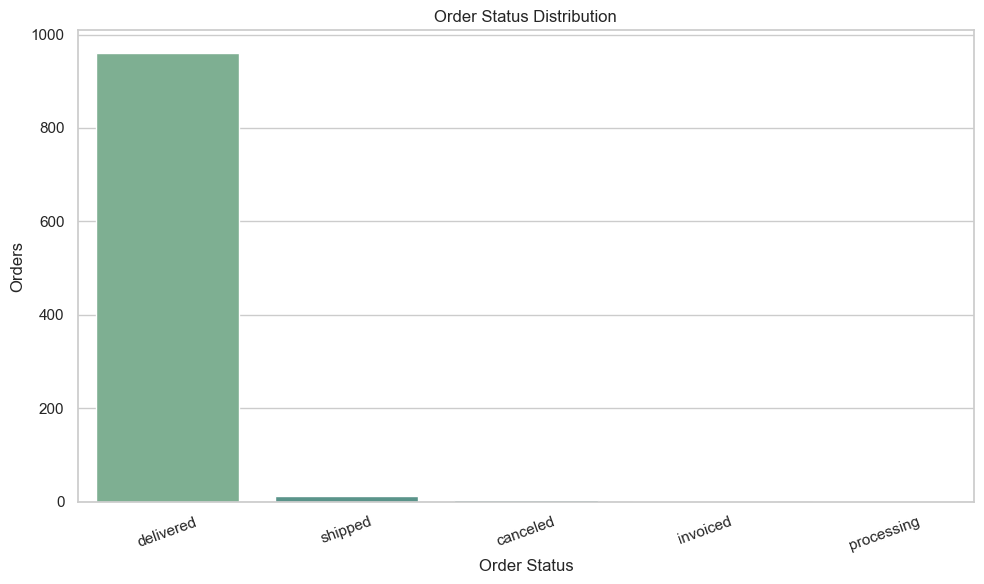

In [39]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=status_distribution_df,
    x="order_status",
    y="order_count",
    hue="order_status",
    dodge=False,
    palette="crest",
    legend=False,
)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Orders")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

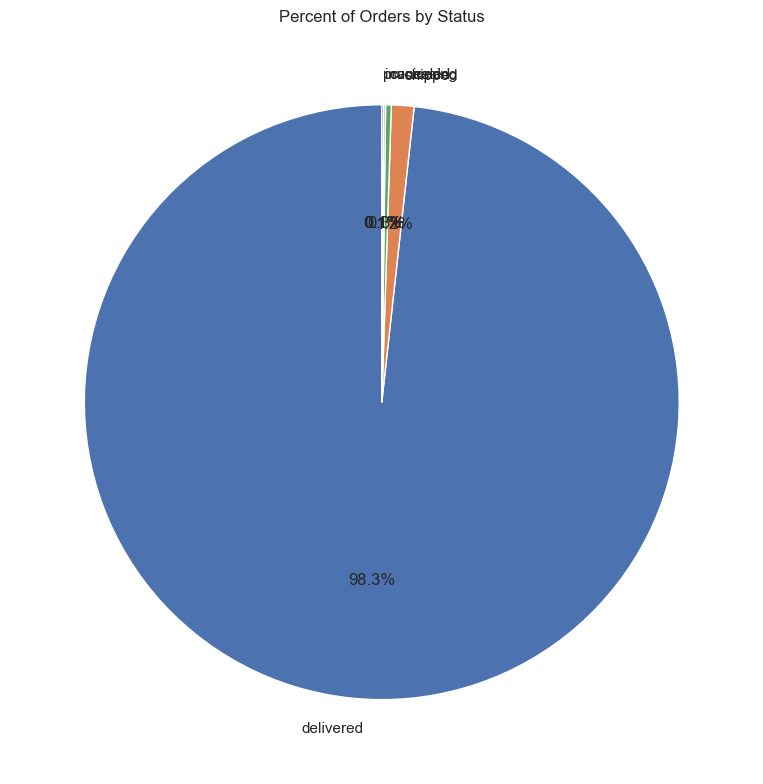

In [40]:
plt.figure(figsize=(8, 8))
plt.pie(
    status_distribution_df["order_count"],
    labels=status_distribution_df["order_status"],
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Percent of Orders by Status")
plt.tight_layout()
plt.show()

In [41]:
top_order_cities_df = (
    df.groupby(["customer_city", "customer_state"], as_index=False)
    .agg(order_count=("Id", "count"))
    .sort_values(["order_count", "customer_city"], ascending=[False, True])
    .head(5)
)

top_order_cities_df

,customer_city,customer_state,order_count
317,Sao Paulo,SP,147
274,Rio De Janeiro,RJ,71
44,Brasilia,DF,24
38,Belo Horizonte,MG,21
90,Curitiba,PR,19


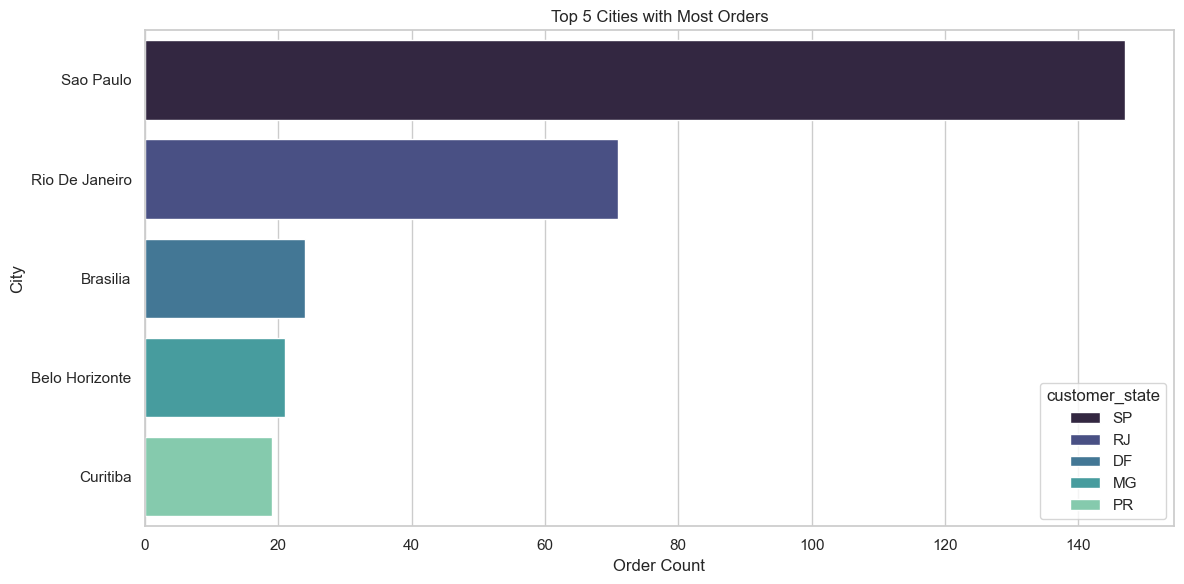

In [42]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_order_cities_df,
    x="order_count",
    y="customer_city",
    hue="customer_state",
    dodge=False,
    palette="mako",
)
plt.title("Top 5 Cities with Most Orders")
plt.xlabel("Order Count")
plt.ylabel("City")
plt.tight_layout()
plt.show()

## Analysis Checklist

In [43]:
sales_by_city_df = (
    df.groupby(["customer_city", "customer_state"], as_index=False)
    .agg(total_sales=("total_order_value", "sum"))
    .sort_values("total_sales", ascending=False)
)
sales_by_city_df["total_sales"] = sales_by_city_df["total_sales"].round(2)

sales_by_city_df.head(10)

,customer_city,customer_state,total_sales
317,Sao Paulo,SP,"18,825.81"
274,Rio De Janeiro,RJ,"12,868.05"
38,Belo Horizonte,MG,"4,084.15"
44,Brasilia,DF,"2,652.86"
90,Curitiba,PR,"2,607.10"
91,Diadema,SP,"1,855.75"
300,Sao Goncalo,RJ,"1,621.56"
105,Fortaleza,CE,"1,601.98"
173,Limeira,SP,"1,573.05"
291,Santo Andre,SP,"1,531.92"


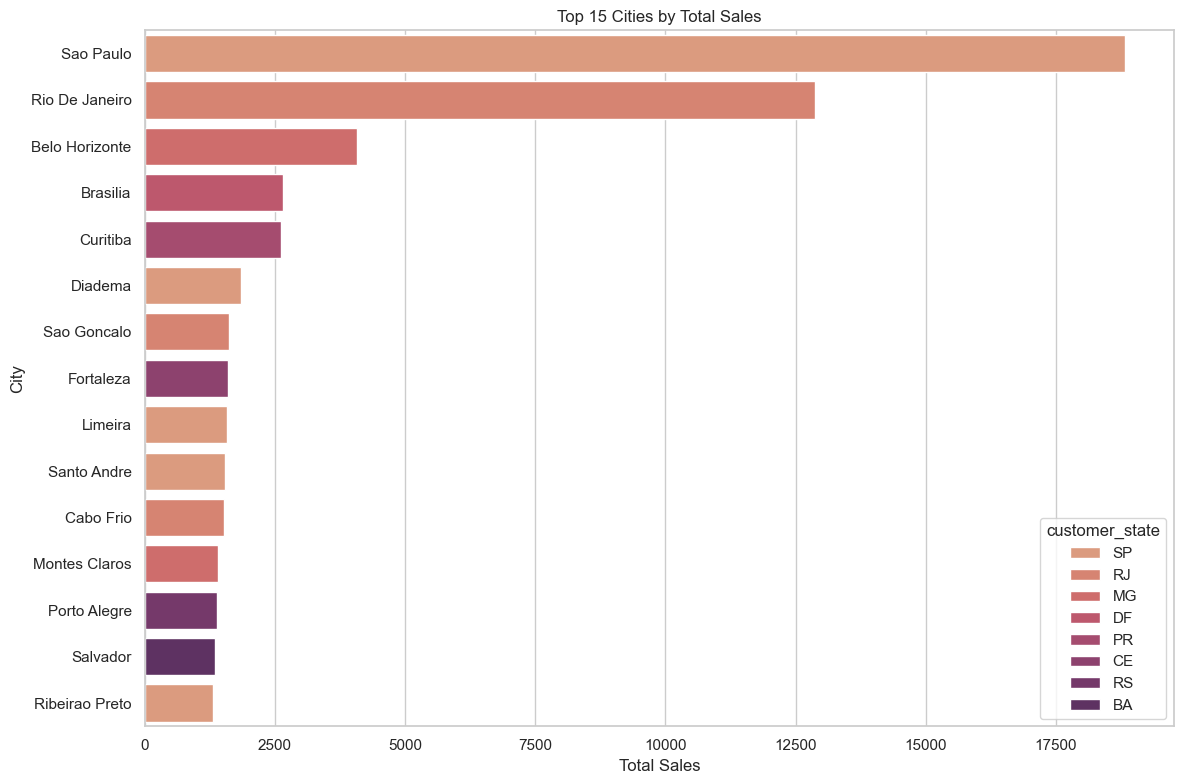

In [44]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=sales_by_city_df.head(15),
    x="total_sales",
    y="customer_city",
    hue="customer_state",
    dodge=False,
    palette="flare",
)
plt.title("Top 15 Cities by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.tight_layout()
plt.show()

In [45]:
correlation_columns = [
    "order_products_value",
    "order_freight_value",
    "order_items_qty",
    "delivery_time_days",
    "review_score",
]
correlation_df = df[correlation_columns].corr().round(4)

correlation_df

,order_products_value,order_freight_value,order_items_qty,delivery_time_days,review_score
order_products_value,1.00,0.47,0.26,-0.02,-0.04
order_freight_value,0.47,1.00,0.63,-0.01,-0.12
order_items_qty,0.26,0.63,1.00,-0.02,-0.10
delivery_time_days,-0.02,-0.01,-0.02,1.00,0.02
review_score,-0.04,-0.12,-0.10,0.02,1.00


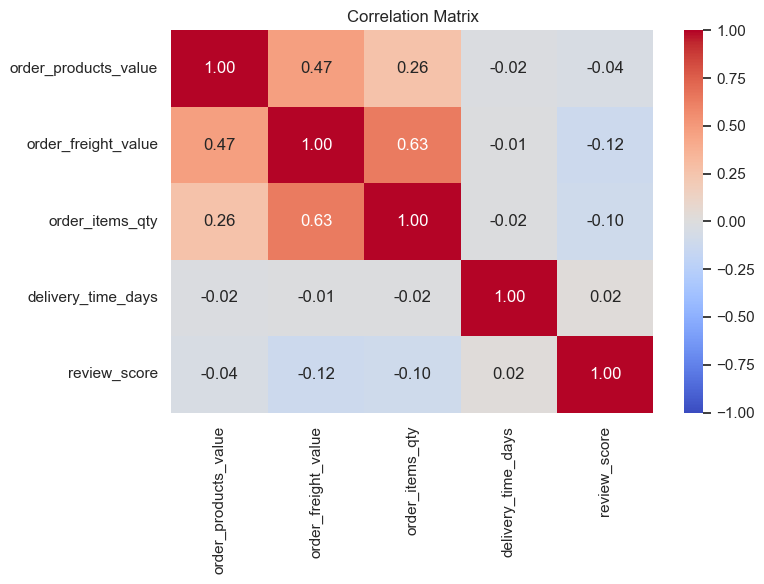

In [46]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_df, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [47]:
timing_summary_df = pd.DataFrame(
    {
        "metric": [
            "average_delivery_time_days",
            "average_approval_delay_hours",
        ],
        "value": [
            df["delivery_time_days"].mean(),
            df["approval_delay_hours"].mean(),
        ],
    }
)

timing_summary_df

,metric,value
0,average_delivery_time_days,12.33
1,average_approval_delay_hours,10.41


In [48]:
average_review_per_order_df = (
    df.groupby("Id", as_index=False)
    .agg(average_review_score=("review_score", "mean"))
    .sort_values("average_review_score", ascending=False)
)

average_review_per_order_df.head(10)

,Id,average_review_score
0,1,5.00
396,408,5.00
767,790,5.00
400,412,5.00
401,413,5.00
762,785,5.00
759,782,5.00
757,780,5.00
754,777,5.00
409,421,5.00


In [49]:
average_review_score_value = average_review_per_order_df["average_review_score"].mean().round(2)
print(f"Average review score per order: {average_review_score_value}")

Average review score per order: 4.09


In [50]:
delivery_by_city_df = (
    df.groupby(["customer_city", "customer_state"], as_index=False)
    .agg(
        average_delivery_time_days=("delivery_time_days", "mean"),
        order_count=("Id", "count"),
    )
    .query("order_count >= 3")
)
delivery_by_city_df["average_delivery_time_days"] = delivery_by_city_df["average_delivery_time_days"].round(2)

fastest_cities_df = delivery_by_city_df.sort_values(
    ["average_delivery_time_days", "order_count"], ascending=[True, False]
).head(3)
slowest_cities_df = delivery_by_city_df.sort_values(
    ["average_delivery_time_days", "order_count"], ascending=[False, False]
).head(3)

print("Top 3 fastest delivery cities")
display(fastest_cities_df)
print("Top 3 slowest delivery cities")
display(slowest_cities_df)

Top 3 fastest delivery cities


,customer_city,customer_state,average_delivery_time_days,order_count
46,Cabo Frio,RJ,5.40,3
234,Pelotas,RS,6.30,3
129,Ipatinga,MG,6.92,3


Top 3 slowest delivery cities


,customer_city,customer_state,average_delivery_time_days,order_count
81,Contagem,MG,24.64,3
216,Orlandia,SP,22.33,3
339,Teresina,PI,20.08,3


In [51]:
review_delivery_df = (
    df.groupby("review_score", as_index=False)
    .agg(
        average_delivery_time_days=("delivery_time_days", "mean"),
        order_count=("Id", "count"),
    )
    .sort_values("review_score")
)
review_delivery_df["average_delivery_time_days"] = review_delivery_df["average_delivery_time_days"].round(2)

review_delivery_df

,review_score,average_delivery_time_days,order_count
0,1,11.92,115
1,2,11.03,25
2,3,12.82,80
3,4,12.06,193
4,5,12.49,565


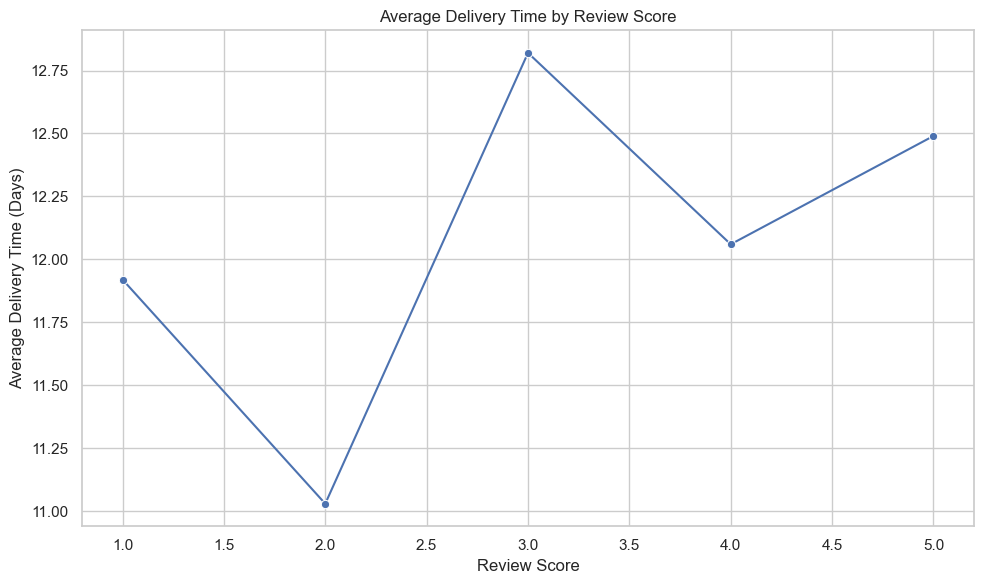

In [52]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=review_delivery_df, x="review_score", y="average_delivery_time_days", marker="o")
plt.title("Average Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Time (Days)")
plt.tight_layout()
plt.show()

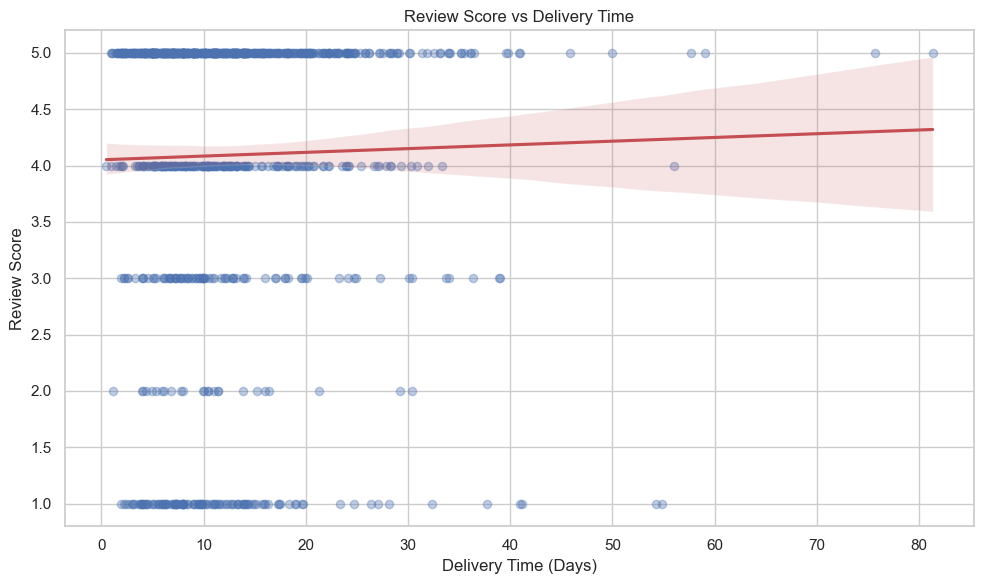

In [53]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x="delivery_time_days",
    y="review_score",
    scatter_kws={"alpha": 0.35, "s": 35},
    line_kws={"color": "#c44e52"},
)
plt.title("Review Score vs Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Review Score")
plt.tight_layout()
plt.show()

## Daily and Weekly Sales Views

In [54]:
daily_sales_df = (
    df.groupby("order_date", as_index=False)
    .agg(total_sales=("total_order_value", "sum"))
    .sort_values("order_date")
)
daily_sales_df["total_sales"] = daily_sales_df["total_sales"].round(2)

daily_sales_df.head(10)

,order_date,total_sales
0,2016-10-05,318.33
1,2017-01-05,162.78
2,2017-01-14,44.57
3,2017-01-21,83.28
4,2017-01-22,159.37
5,2017-01-23,111.13
6,2017-01-25,31.78
7,2017-01-26,101.93
8,2017-01-27,262.94
9,2017-01-28,53.37


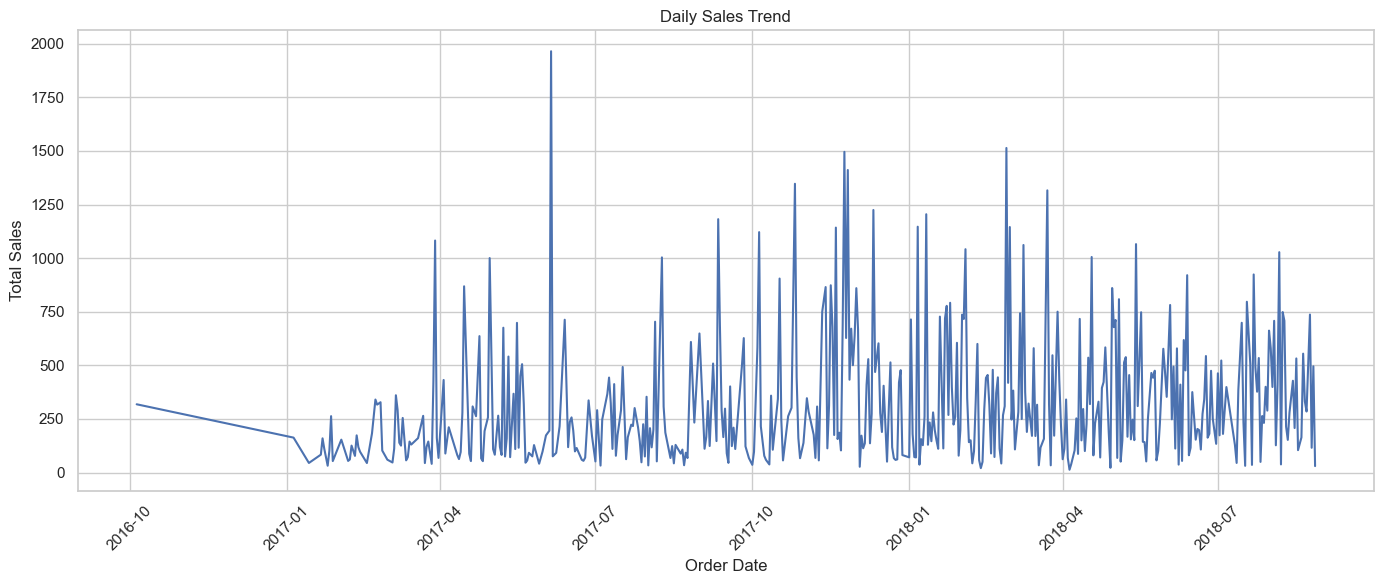

In [55]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_sales_df, x="order_date", y="total_sales")
plt.title("Daily Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
weekly_sales_df = (
    df.groupby("order_week", as_index=False)
    .agg(total_sales=("total_order_value", "sum"))
    .sort_values("order_week")
)
weekly_sales_df["total_sales"] = weekly_sales_df["total_sales"].round(2)

weekly_sales_df.head(10)

,order_week,total_sales
0,2016-10-03/2016-10-09,318.33
1,2017-01-02/2017-01-08,162.78
2,2017-01-09/2017-01-15,44.57
3,2017-01-16/2017-01-22,242.65
4,2017-01-23/2017-01-29,561.15
5,2017-01-30/2017-02-05,153.26
6,2017-02-06/2017-02-12,609.87
7,2017-02-13/2017-02-19,141.18
8,2017-02-20/2017-02-26,"1,270.35"
9,2017-02-27/2017-03-05,217.66


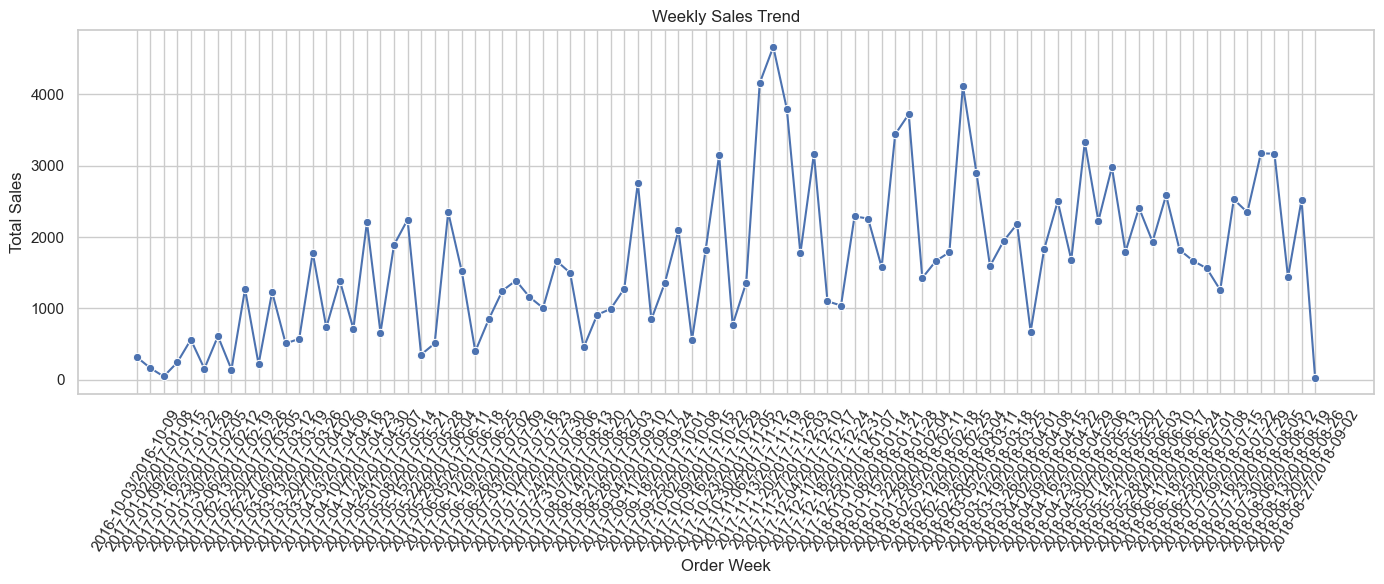

In [58]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=weekly_sales_df, x="order_week", y="total_sales", marker="o")
plt.title("Weekly Sales Trend")
plt.xlabel("Order Week")
plt.ylabel("Total Sales")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## Product Orders by Year

In [59]:
products_per_year_df = (
    df.dropna(subset=["order_year", "order_items_qty"])
    .groupby("order_year", as_index=False)["order_items_qty"]
    .sum()
    .sort_values("order_year")
)

products_per_year_df

,order_year,order_items_qty
0,2016,2
1,2017,498
2,2018,567


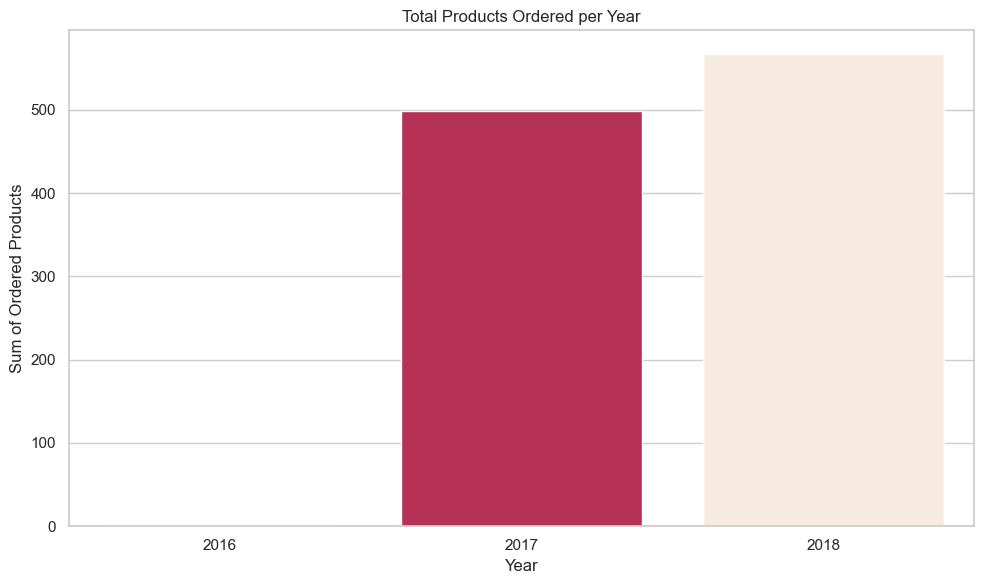

In [60]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=products_per_year_df,
    x="order_year",
    y="order_items_qty",
    hue="order_year",
    dodge=False,
    palette="rocket",
    legend=False,
)
plt.title("Total Products Ordered per Year")
plt.xlabel("Year")
plt.ylabel("Sum of Ordered Products")
plt.tight_layout()
plt.show()

## Spark Output Check

,customer_city,customer_state,total_sales,avg_delivery_days,avg_review_score
0,Sao Paulo,SP,"18,825.81",13.00,4.24
1,Rio De Janeiro,RJ,"12,868.05",12.59,4.13
2,Belo Horizonte,MG,"4,084.15",12.57,3.95
3,Brasilia,DF,"2,652.86",10.72,3.79
4,Curitiba,PR,"2,607.10",13.74,3.95
5,Diadema,SP,"1,855.75",7.33,3.00
6,Sao Goncalo,RJ,"1,621.56",13.41,3.86
7,Fortaleza,CE,"1,601.98",10.73,4.22
8,Limeira,SP,"1,573.05",14.19,3.67
9,Santo Andre,SP,"1,531.92",11.99,4.64


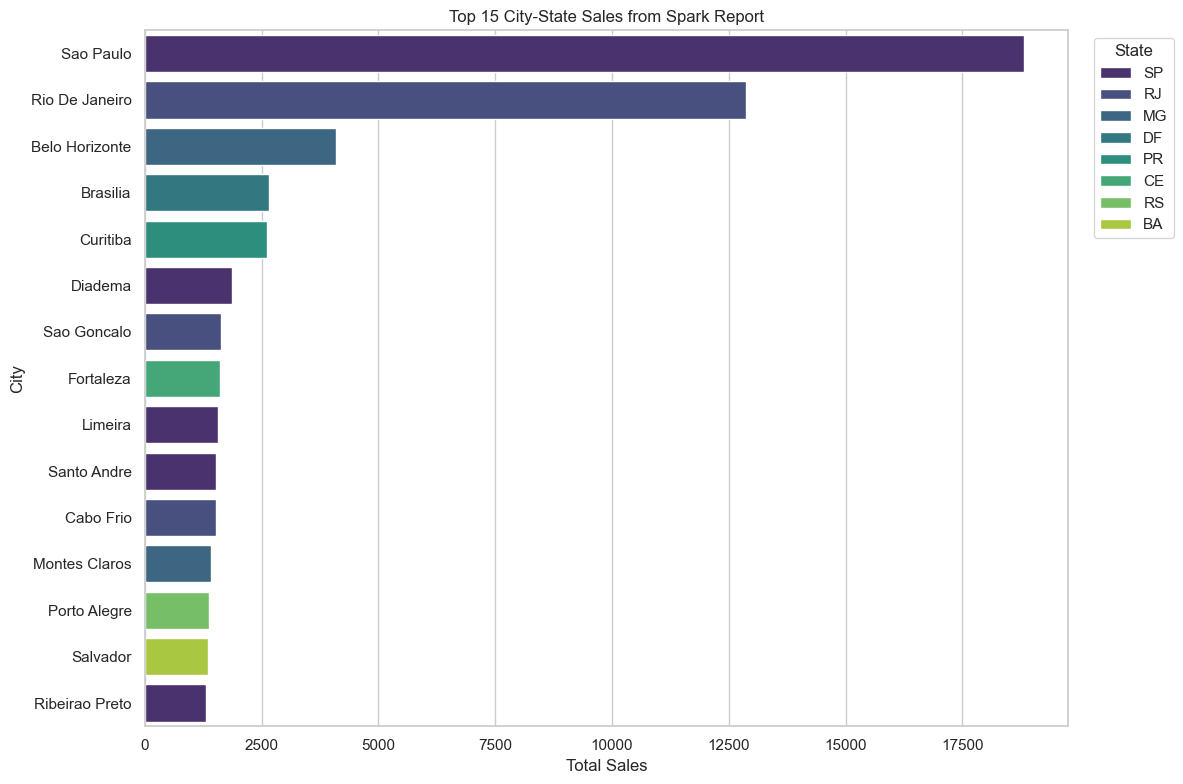

In [61]:
if not city_report_df.empty:
    display(city_report_df.head(10))
    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=city_report_df.sort_values("total_sales", ascending=False).head(15),
        x="total_sales",
        y="customer_city",
        hue="customer_state",
        dodge=False,
        palette="viridis",
    )
    plt.title("Top 15 City-State Sales from Spark Report")
    plt.xlabel("Total Sales")
    plt.ylabel("City")
    plt.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No Spark city report found under output/sales_by_city_report/")